<center><h1>Xie_Zihan_HW2</h1></center>
<br>
<br>

Name: Zihan Xie
<br>
Github Username: SherryXiYe
<br>
USC ID: 6376813348

# 0. Environment Setup

Required Python packages are listed in `requirements.txt`.

To install the dependencies, run:

```bash
pip install -r requirements.txt

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from io import BytesIO
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


Matplotlib is building the font cache; this may take a moment.


Get the Cycle Power Plant Data Set

In [4]:

local_candidates = ["Folds5x2_pp.xlsx", "./data/CCPP/Folds5x2_pp.xlsx"]
for path in local_candidates:
    if os.path.exists(path):
        data = pd.read_excel(path, sheet_name=0)
        print(f"Loaded local workbook: {path} (Sheet 1)")
        break
else:
    uci_zip_url = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"
    import requests
    response = requests.get(uci_zip_url, timeout=60)
    response.raise_for_status()
    with ZipFile(BytesIO(response.content)) as z:
        xlsx_names = [name for name in z.namelist() if name.lower().endswith("folds5x2_pp.xlsx")]
        if not xlsx_names:
            raise FileNotFoundError("Folds5x2_pp.xlsx was not found in the official UCI archive.")
        with z.open(xlsx_names[0]) as xlsx_file:
            data = pd.read_excel(xlsx_file, sheet_name=0)
        print("Downloaded the official UCI workbook and loaded Sheet 1.")

data.columns = [c.strip() for c in data.columns]
data = data[["AT", "V", "AP", "RH", "PE"]].copy()
print("Data shape:", data.shape)
data.head()


Loaded local workbook: ./data/CCPP/Folds5x2_pp.xlsx (Sheet 1)
Data shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.960000,41.760000,1024.070000,73.170000,463.260000
1,25.180000,62.960000,1020.040000,59.080000,444.370000
2,5.110000,39.400000,1012.160000,92.140000,488.560000
3,20.860000,57.320000,1010.240000,76.640000,446.480000
4,10.820000,37.500000,1009.230000,96.620000,473.900000


### (b) Exploring the data

#### i. rows and columns

In [5]:
rows, cols = data.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")


Rows: 9568
Columns: 5


>**Answer:** 
>
> Rows: 9568
>
> Columns: 5
>
> Each row represents one hourly observation from the power plant.
>
> Columns: AT (ambient temperature), V (exhaust vacuum), AP (ambient pressure), RH (relative humidity), PE (net hourly electrical energy output).

#### ii. Pairwise scatterplots of all the variables


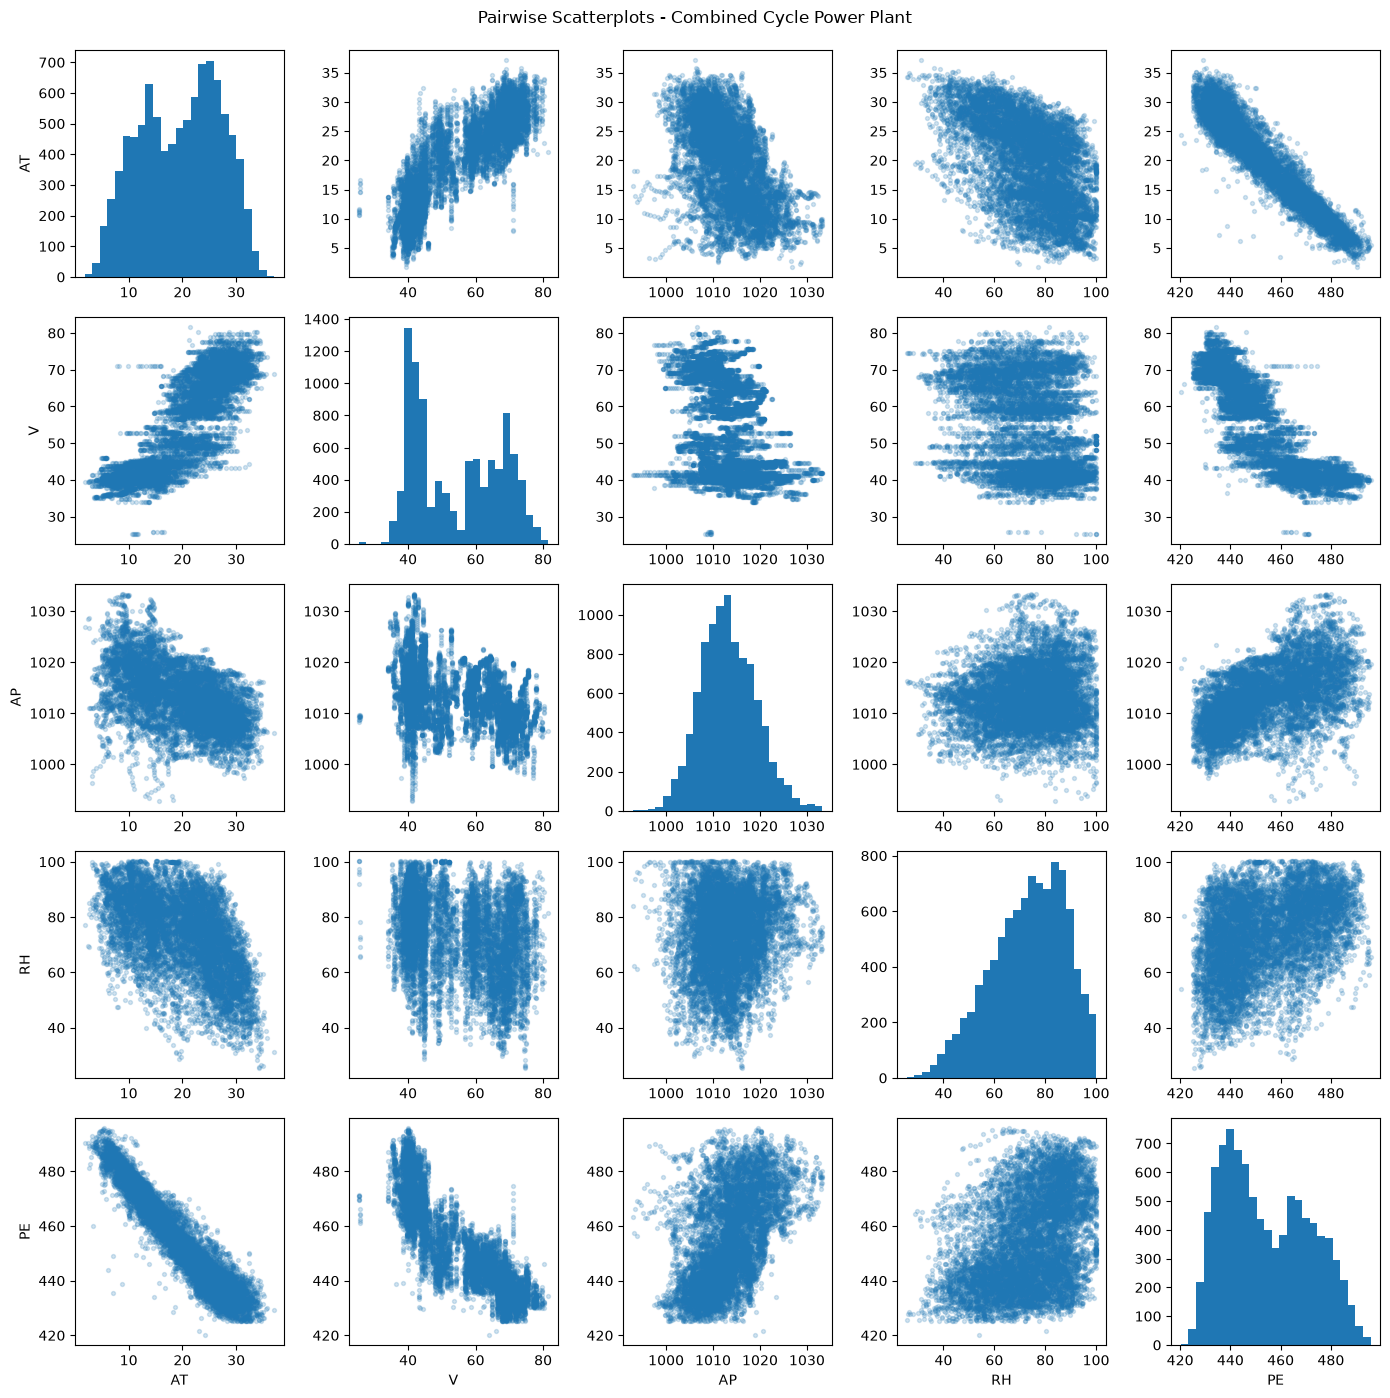

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
cols = ["AT", "V", "AP", "RH", "PE"]
for i, row_var in enumerate(cols):
    for j, col_var in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(data[row_var], bins=25)
        else:
            ax.scatter(data[col_var], data[row_var], s=8, alpha=0.20)
        if i == len(cols) - 1:
            ax.set_xlabel(col_var)
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(row_var)
        else:
            ax.set_ylabel("")
plt.suptitle("Pairwise Scatterplots - Combined Cycle Power Plant", y=0.995)
plt.tight_layout()
plt.show()


> **Answer:**
> 
> The pairwise scatterplots show that AT and V have strong negative associations with PE. In particular, the relationship between AT and PE appears approximately linear and is stronger than the marginal relationships observed for AP and RH.
>
> AP and RH show weaker positive marginal associations with PE. In addition, some of the predictors are correlated with each other, especially AT and V, suggesting that their regression coefficients may change when they are included together in a multiple regression model.
>
> There is also some evidence of curvature in several predictor-response relationships, which motivates the polynomial regression analysis in part (f).
>

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [7]:
summary = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})
summary


,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345000,35.300000,13.510000,25.720000,12.210000
V,54.305804,52.080000,56.200000,41.740000,66.540000,24.800000
AP,1013.259078,1012.940000,40.410000,1009.100000,1017.260000,8.160000
RH,73.308978,74.975000,74.600000,63.327500,84.830000,21.502500
PE,454.365009,451.550000,75.500000,439.750000,468.430000,28.680000


### (c) Simple Linear Regression

For each predictor $X$, fit $PE=\beta_0+\beta_1X+\epsilon$. Use $H_0:\beta_1=0$ and $\alpha=0.05$ to assess whether the predictor has a statistically significant linear association with PE. The plots and Cook's-distance diagnostics support the statistical conclusions.

Simple Linear Regression Results


,Intercept,Coefficient,p-value,R-squared,Significant (p<0.05)
Predictor,,,,,
AT,497.034120,-2.171320,0.000000,0.898948,True
V,517.801526,-1.168135,0.000000,0.756518,True
AP,-1055.260989,1.489872,0.000000,0.268769,True
RH,420.961766,0.455650,0.000000,0.151939,True


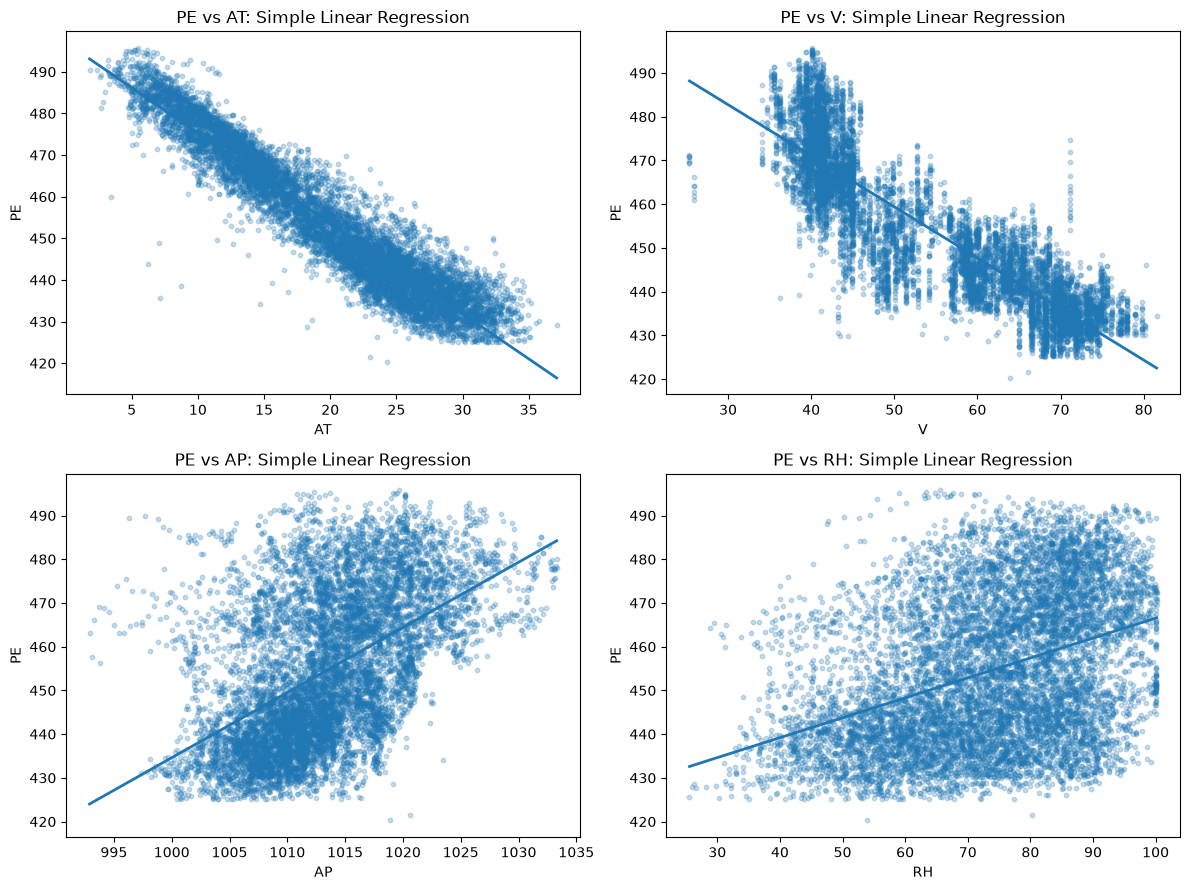

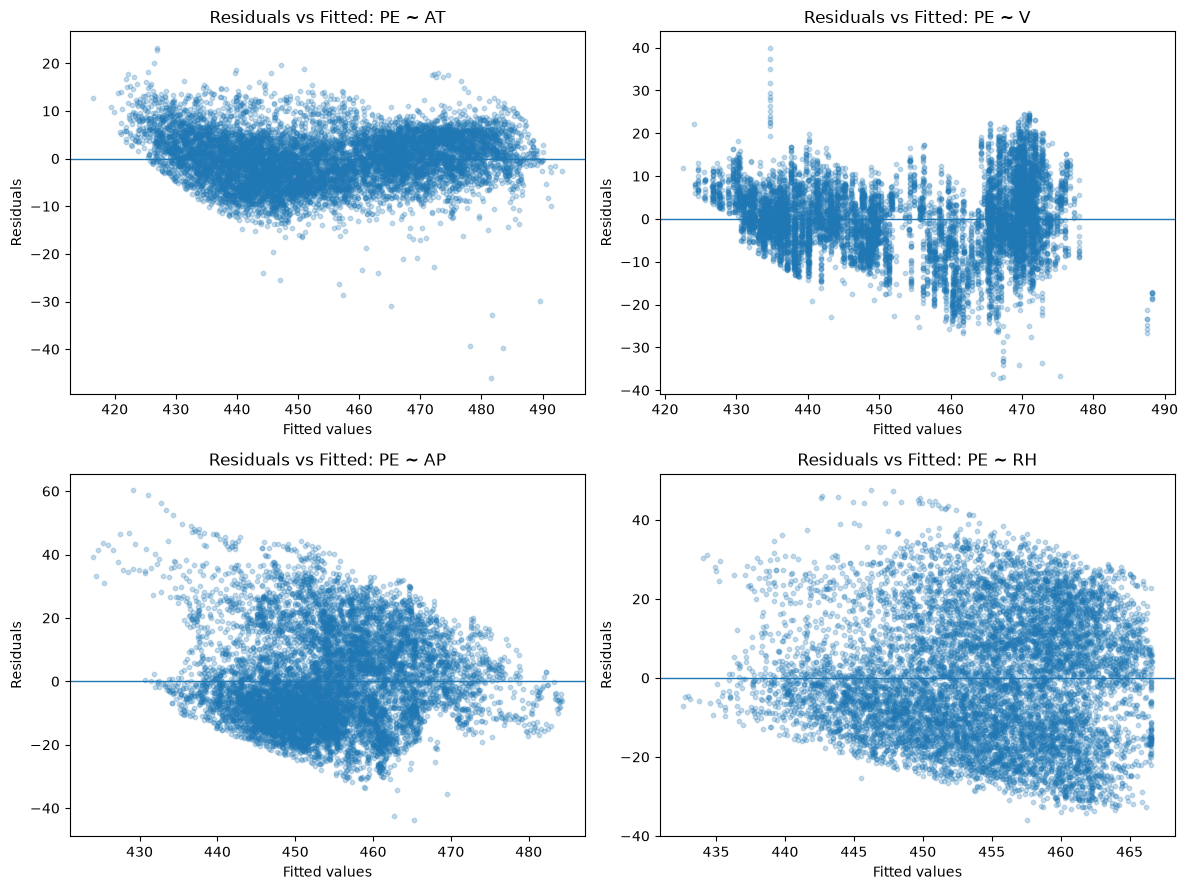

Outlier / Influence Diagnostics


,Potential outliers (|studentized residual| > 3),Max Cook's D,Cook's D cutoff (4/n),Observations above 4/n
Predictor,,,,
AT,42,0.014325,0.000418,416
V,33,0.003243,0.000418,423
AP,29,0.008152,0.000418,300
RH,2,0.002059,0.000418,249


In [8]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_rows = []

# Fit a simple linear regression model for each predictor
for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=data).fit()
    simple_models[x] = model

    simple_rows.append({
        "Predictor": x,
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[x],
        "p-value": model.pvalues[x],
        "R-squared": model.rsquared,
        "Significant (p<0.05)": model.pvalues[x] < 0.05
    })

simple_results = pd.DataFrame(simple_rows).set_index("Predictor")

print("Simple Linear Regression Results")
display(simple_results.round(6))


# Plot scatterplots with fitted regression lines
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, x in zip(axes, predictors):
    ax.scatter(data[x], data["PE"], s=10, alpha=0.25)

    grid = np.linspace(data[x].min(), data[x].max(), 300)
    pred_df = pd.DataFrame({x: grid})

    ax.plot(
        grid,
        simple_models[x].predict(pred_df),
        linewidth=2
    )

    ax.set_xlabel(x)
    ax.set_ylabel("PE")
    ax.set_title(f"PE vs {x}: Simple Linear Regression")

plt.tight_layout()
plt.show()


# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, x in zip(axes, predictors):
    model = simple_models[x]

    ax.scatter(
        model.fittedvalues,
        model.resid,
        s=10,
        alpha=0.25
    )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs Fitted: PE ~ {x}")

plt.tight_layout()
plt.show()


# Outlier and influence diagnostics
diagnostic_rows = []

for x, model in simple_models.items():
    influence = model.get_influence()

    # Studentized residuals: potential response outliers
    studentized_resid = influence.resid_studentized_internal
    n_outliers = (np.abs(studentized_resid) > 3).sum()

    # Cook's distance: influential observations
    cooks_d = influence.cooks_distance[0]
    cutoff = 4 / len(data)
    n_influential = (cooks_d > cutoff).sum()

    diagnostic_rows.append({
        "Predictor": x,
        "Potential outliers (|studentized residual| > 3)": int(n_outliers),
        "Max Cook's D": cooks_d.max(),
        "Cook's D cutoff (4/n)": cutoff,
        "Observations above 4/n": int(n_influential)
    })

diagnostic_results = pd.DataFrame(diagnostic_rows).set_index("Predictor")

print("Outlier / Influence Diagnostics")
display(diagnostic_results.round(6))


> **Answer:**
>
> For each predictor, a simple linear regression model was fitted with PE as the response.
>
> AT has a strong negative linear association with PE. The estimated slope is -2.171, meaning that a one-unit increase in AT is associated with an average decrease of approximately 2.171 units in PE. The model has \(R^2=0.899\), so AT alone explains about 89.9% of the variation in PE.
>
> V also has a strong negative association with PE, with an estimated slope of -1.168 and \(R^2=0.757\). AP has a positive estimated slope of 1.490, but its relationship with PE is weaker, with \(R^2=0.269\). RH has a positive slope of 0.456 and the weakest \(R^2\) among the four predictors, at 0.152.
>
> All four predictors have p-values below 0.05. Therefore, we reject the null hypothesis \(H_0:\beta_1=0\) for all four simple linear regression models and conclude that each predictor has a statistically significant univariate linear association with PE.
>
> The scatterplots and fitted regression lines support these conclusions. The residual plots also provide useful diagnostics for identifying unusual observations and checking whether a simple linear form is adequate.
>
> For outlier diagnostics, observations with absolute studentized residuals greater than 3 were treated as potential response outliers. Although some observations meet this criterion, the Cook's distances should also be considered when evaluating their influence on the fitted models. Since there is no evidence that these observations are erroneous measurements or that any single observation has an extreme influence, I would not remove observations solely on the basis of these diagnostics.


### (d) Multiple Regression

Fit $PE=\beta_0+\beta_1AT+\beta_2V+\beta_3AP+\beta_4RH+\epsilon$.

In [9]:
X = data[predictors]
y = data["PE"]
X_sm = sm.add_constant(X)
multiple_model = sm.OLS(y, X_sm).fit()

print(multiple_model.summary())

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues,
    "Significant (p<0.05)": multiple_model.pvalues < 0.05
})
display(multiple_results.round(6))

for x in predictors:
    decision = "reject H0" if multiple_model.pvalues[x] < 0.05 else "fail to reject H0"
    print(f"{x}: p={multiple_model.pvalues[x]:.6g} -> {decision} for H0: beta_{x}=0")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:39:42   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

,Coefficient,p-value,Significant (p<0.05)
const,454.609274,0.000000,True
AT,-1.977513,0.000000,True
V,-0.233916,0.000000,True
AP,0.062083,0.000000,True
RH,-0.158054,0.000000,True


AT: p=0 -> reject H0 for H0: beta_AT=0
V: p=4.37531e-215 -> reject H0 for H0: beta_V=0
AP: p=5.50711e-11 -> reject H0 for H0: beta_AP=0
RH: p=3.10458e-293 -> reject H0 for H0: beta_RH=0


> **Answer:** 
>
> The multiple regression model is
>
> $$PE = \beta_0 + \beta_1 AT + \beta_2 V + \beta_3 AP + \beta_4 RH + \epsilon.$$
>
> The fitted model explains about 93% of the variability in PE ($R^2 \approx 0.929$). All four predictors have p-values below 0.05, so we reject $H_0:\beta_j=0$ for AT, V, AP, and RH in the multiple regression. Holding the other predictors fixed, AT, V, and RH have negative coefficients, whereas AP has a positive coefficient.

### (e) 1c Compare to 1d

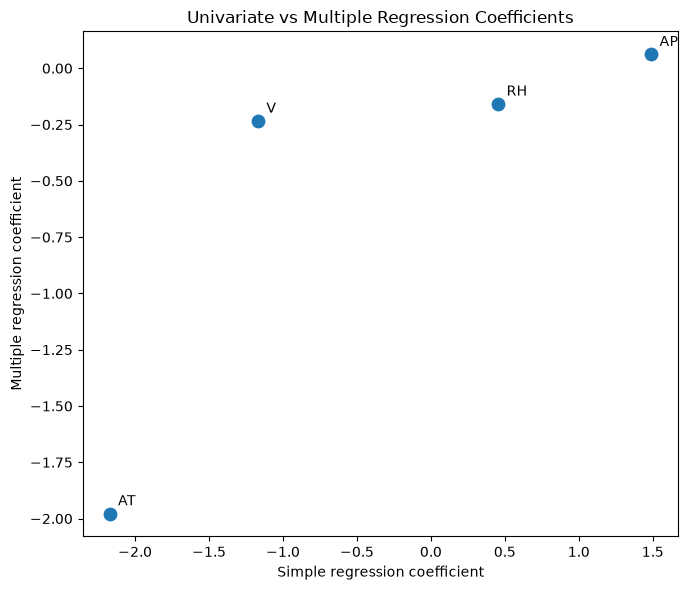

,Simple,Multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


In [10]:
simple_coef = simple_results["Coefficient"]
multiple_coef = multiple_model.params[predictors]
coef_compare = pd.DataFrame({
    "Simple": simple_coef,
    "Multiple": multiple_coef
})

plt.figure(figsize=(7, 6))
plt.scatter(coef_compare["Simple"], coef_compare["Multiple"], s=80)
for name, row in coef_compare.iterrows():
    plt.annotate(name, (row["Simple"], row["Multiple"]), xytext=(6, 6), textcoords="offset points")
plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Univariate vs Multiple Regression Coefficients")
plt.tight_layout()
plt.show()

display(coef_compare.round(6))


> **Answer:**
>
> The coefficient plot compares each predictor's simple-regression coefficient with its multiple-regression coefficient. Differences are expected when predictors share information or are correlated.
>
> The coefficients from the simple and multiple regression models differ substantially for several predictors. The AT coefficient changes relatively little, from -2.171 to -1.978. In contrast, the magnitude of the V coefficient decreases from -1.168 to -0.234, and the AP coefficient decreases from 1.490 to 0.062. Most notably, the RH coefficient changes sign, from +0.456 in the simple regression to -0.158 in the multiple regression. These differences occur because the predictors are correlated. The simple regression coefficients represent marginal associations, whereas the multiple regression coefficients represent associations after controlling for the other predictors.

### (f) Nonlinear Association


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_61640\3708228487.py:7: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols(f"PE ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()


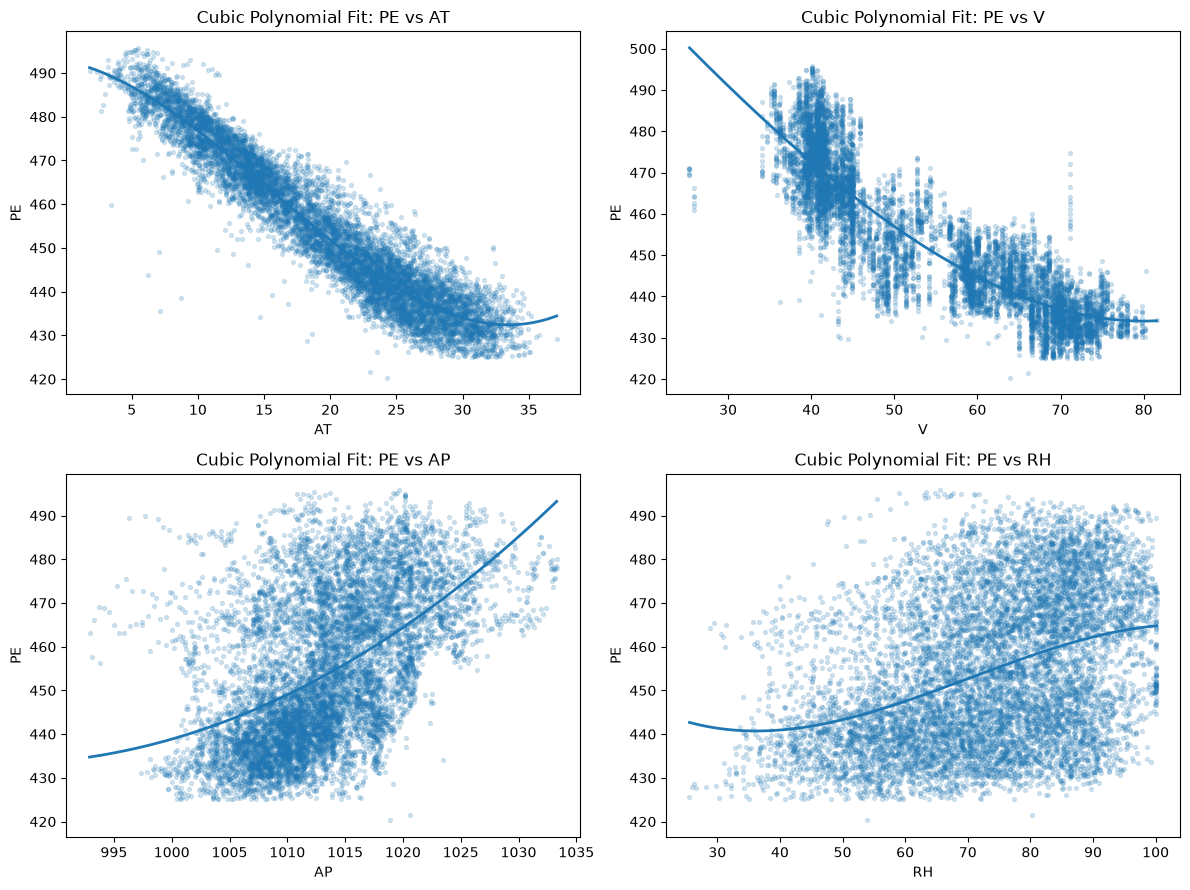

,p(linear),p(quadratic),p(cubic),R-squared
Predictor,,,,
AT,0.000001,0.000000,0.000000,0.911883
V,0.000025,0.768497,0.013735,0.775022
AP,0.000000,0.000000,0.000000,0.274863
RH,0.000377,0.000009,0.000014,0.153743


Predictors with significant quadratic terms: ['AT', 'AP', 'RH']
Predictors with significant cubic terms: ['AT', 'V', 'AP', 'RH']


In [11]:
poly_models = {}
poly_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, x in zip(axes, predictors):
    model = smf.ols(f"PE ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()
    poly_models[x] = model
    quad_term = f"I({x} ** 2)"
    cubic_term = f"I({x} ** 3)"
    poly_rows.append({
        "Predictor": x,
        "p(linear)": model.pvalues[x],
        "p(quadratic)": model.pvalues[quad_term],
        "p(cubic)": model.pvalues[cubic_term],
        "R-squared": model.rsquared
    })
    grid = np.linspace(data[x].min(), data[x].max(), 300)
    pred = model.predict(pd.DataFrame({x: grid}))
    ax.scatter(data[x], data["PE"], s=8, alpha=0.18)
    ax.plot(grid, pred, linewidth=2)
    ax.set_xlabel(x)
    ax.set_ylabel("PE")
    ax.set_title(f"Cubic Polynomial Fit: PE vs {x}")

poly_results = pd.DataFrame(poly_rows).set_index("Predictor")
plt.tight_layout()
plt.show()
display(poly_results.round(8))

quad_sig = poly_results.index[poly_results["p(quadratic)"] < 0.05].tolist()
cubic_sig = poly_results.index[poly_results["p(cubic)"] < 0.05].tolist()
print("Predictors with significant quadratic terms:", quad_sig if quad_sig else "None")
print("Predictors with significant cubic terms:", cubic_sig if cubic_sig else "None")


> **Answer:**
>
> For each predictor $X$, fit $PE=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon$. Evidence of nonlinearity is assessed by the significance of the higher-order terms and the fitted curves. A significant quadratic or cubic term indicates that a straight-line relationship is not sufficient for that predictor.
>
> There is evidence of nonlinear association between PE and all four predictors. For AT, AP, and RH, both the quadratic and cubic terms are statistically significant. For V, the quadratic term is not significant (\(p=0.768\)), but the cubic term is significant (\(p=0.0137\)). Therefore, each predictor has at least one significant higher-order term, providing evidence that a purely linear relationship is not sufficient.

### (g) Interactions of Predictors

Fit a full model containing all four main effects and the six pairwise interaction terms: AT:V, AT:AP, AT:RH, V:AP, V:RH, and AP:RH. Interaction terms with p-values below 0.05 are statistically significant.

In [12]:
interaction_terms = ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"]
interaction_formula = "PE ~ " + " + ".join(predictors + interaction_terms)
interaction_model = smf.ols(interaction_formula, data=data).fit()
interaction_table = pd.DataFrame({
    "Coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues
})

print(interaction_model.summary())
print("\nInteraction terms:")
display(interaction_table.loc[interaction_terms].round(8))
significant_interactions = [t for t in interaction_terms if interaction_model.pvalues[t] < 0.05]
print("Significant interaction terms (p<0.05):", significant_interactions if significant_interactions else "None")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:39:43   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,Coefficient,p-value
AT:V,0.020971,0.000000
AT:AP,0.001759,0.452051
AT:RH,-0.005230,0.000000
V:AP,0.006812,0.000000
V:RH,0.000839,0.086194
AP:RH,-0.001612,0.033606


Significant interaction terms (p<0.05): ['AT:V', 'AT:RH', 'V:AP', 'AP:RH']


> **Answer:**
>
> The full interaction model provides evidence of several significant pairwise interactions. At the 0.05 significance level, AT:V, AT:RH, V:AP, and AP:RH are statistically significant. AT:AP (\(p=0.452\)) and V:RH (\(p=0.086\)) are not statistically significant. Thus, the association between some predictors and PE depends on the levels of other predictors.

### (h) Improvement

Use the same random 70/30 split for both candidate regression models. The baseline uses all four predictors. The expanded model adds all quadratic terms and all pairwise interactions, then removes insignificant terms by p-value while respecting model hierarchy.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

train_df = pd.concat([X_train, y_train], axis=1)

base_formula = "PE ~ AT + V + AP + RH"
base_model = smf.ols(base_formula, data=train_df).fit()

base_train_pred = base_model.predict(X_train)
base_test_pred = base_model.predict(X_test)
base_train_mse = mean_squared_error(y_train, base_train_pred)
base_test_mse = mean_squared_error(y_test, base_test_pred)


quadratic_terms = [f"I({p} ** 2)" for p in predictors]
all_terms = predictors + quadratic_terms + interaction_terms
current_terms = all_terms.copy()
alpha = 0.05


def has_higher_order_dependency(main_effect, terms):
    
    quadratic_term = f"I({main_effect} ** 2)"
    if quadratic_term in terms:
        return True

    for term in terms:
        if ":" in term:
            variables = term.split(":")
            if main_effect in variables:
                return True
    
    return False


while True:

    formula = "PE ~ " + " + ".join(current_terms)
    model = smf.ols(formula, data=train_df).fit()

    removable = []

    for term in current_terms:
        pval = model.pvalues[term]
        if pval < alpha:
            continue
        if term in predictors:
            if has_higher_order_dependency(term, current_terms):
                continue
        removable.append((pval, term))

    if not removable:
        final_model = model
        break

    removable.sort(key=lambda x: x[0], reverse=True)
    worst_pval, worst_term = removable[0]

    print(
        f"Removing: {worst_term:15s} "
        f"(p-value = {worst_pval:.6f})"
    )

    current_terms.remove(worst_term)

final_train_pred = final_model.predict(X_train)
final_test_pred = final_model.predict(X_test)
final_train_mse = mean_squared_error(
    y_train, final_train_pred
)
final_test_mse = mean_squared_error(
    y_test, final_test_pred
)

improvement = (
    (base_test_mse - final_test_mse)
    / base_test_mse
    * 100
)

improvement_results = pd.DataFrame({
    "Model": [
        "Baseline multiple linear regression",
        "Selected nonlinear + interaction model"
    ],
    "Number of terms": [
        len(predictors),
        len(current_terms)
    ],
    "Train MSE": [
        base_train_mse,
        final_train_mse
    ],
    "Test MSE": [
        base_test_mse,
        final_test_mse
    ]
})

print("\nSelected terms:")
for term in current_terms:
    print(f"  {term}")

print("\nFinal model formula:")
print("PE ~ " + " + ".join(current_terms))

print("\nFinal model summary:")
print(final_model.summary())

print("\nTrain/Test MSE comparison:")
display(improvement_results.round(6))

print(f"\nTest MSE improvement: {improvement:.2f}%")


Removing: V:RH            (p-value = 0.867382)
Removing: I(V ** 2)       (p-value = 0.607733)
Removing: V:AP            (p-value = 0.357826)

Selected terms:
  AT
  V
  AP
  RH
  I(AT ** 2)
  I(AP ** 2)
  I(RH ** 2)
  AT:V
  AT:AP
  AT:RH
  AP:RH

Final model formula:
PE ~ AT + V + AP + RH + I(AT ** 2) + I(AP ** 2) + I(RH ** 2) + AT:V + AT:AP + AT:RH + AP:RH

Final model summary:
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:39:43   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                    

,Model,Number of terms,Train MSE,Test MSE
0,Baseline multiple linear regression,4,20.580840,21.239857
1,Selected nonlinear + interaction model,11,17.890843,18.660040



Test MSE improvement: 12.15%


> **Answer:**
>
> The baseline multiple linear regression has a training MSE of 20.581 and a test MSE of 21.240. After adding quadratic and interaction terms and removing insignificant terms using p-values while respecting the hierarchy principle, the selected model has a training MSE of 17.891 and a test MSE of 18.660. Thus, the nonlinear/interaction model reduces the test MSE by approximately 12.1% relative to the baseline model. This indicates that incorporating nonlinearities and interactions improves out-of-sample prediction on this train/test split.

### (i) KNN

Best raw-feature k: 5 with test MSE 15.726820
Best normalized-feature k: 4 with test MSE 14.305669


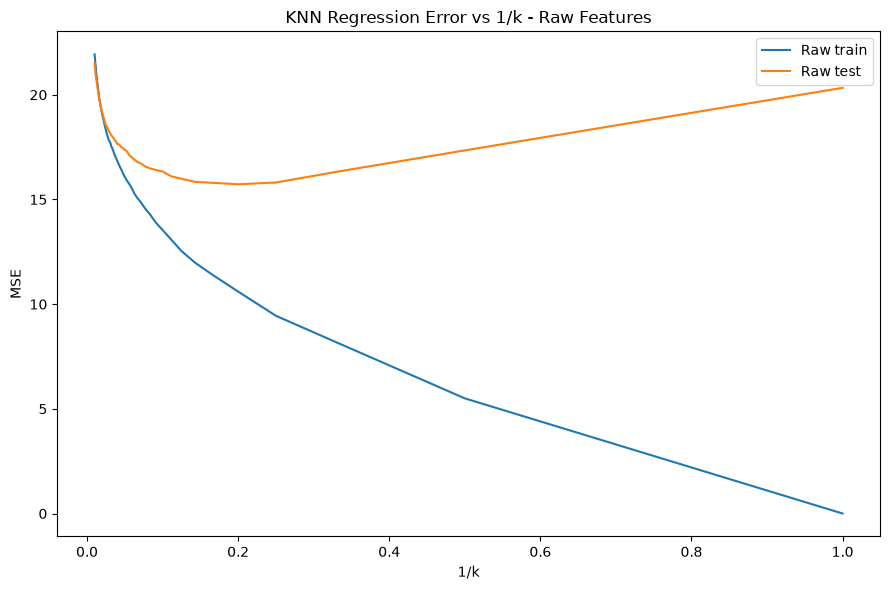

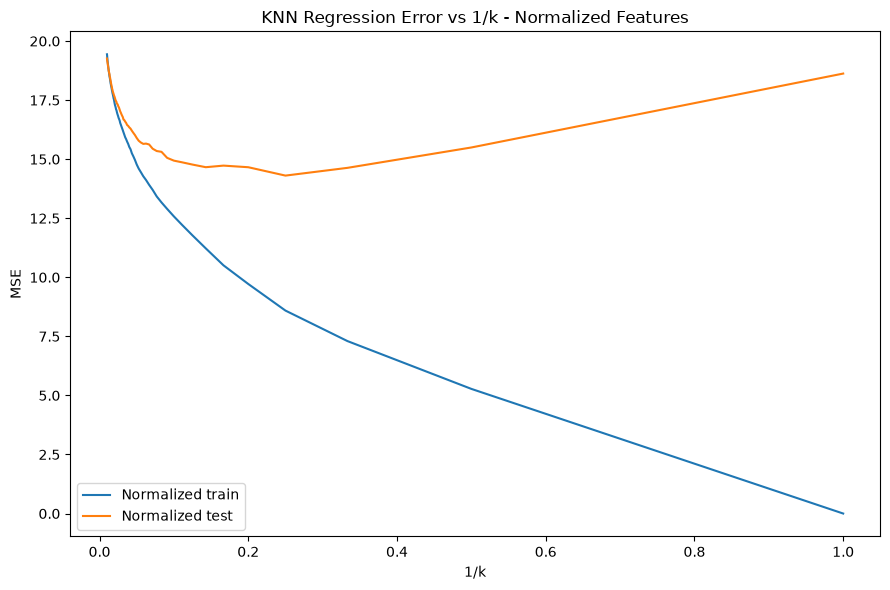

,Features,Best k,Best train MSE,Best test MSE
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.591433,14.305669


In [14]:
raw_train, raw_test = X_train.copy(), X_test.copy()

scaler = StandardScaler()
norm_train = scaler.fit_transform(raw_train)
norm_test = scaler.transform(raw_test)

ks = np.arange(1, 101)
raw_train_mse, raw_test_mse = [], []
norm_train_mse, norm_test_mse = [], []

for k in ks:
    raw_knn = KNeighborsRegressor(n_neighbors=k)
    raw_knn.fit(raw_train, y_train)
    raw_train_mse.append(mean_squared_error(y_train, raw_knn.predict(raw_train)))
    raw_test_mse.append(mean_squared_error(y_test, raw_knn.predict(raw_test)))

    norm_knn = KNeighborsRegressor(n_neighbors=k)
    norm_knn.fit(norm_train, y_train)
    norm_train_mse.append(mean_squared_error(y_train, norm_knn.predict(norm_train)))
    norm_test_mse.append(mean_squared_error(y_test, norm_knn.predict(norm_test)))

raw_best_idx = int(np.argmin(raw_test_mse))
norm_best_idx = int(np.argmin(norm_test_mse))

knn_results = pd.DataFrame({
    "k": ks,
    "1/k": 1 / ks,
    "Raw Train MSE": raw_train_mse,
    "Raw Test MSE": raw_test_mse,
    "Normalized Train MSE": norm_train_mse,
    "Normalized Test MSE": norm_test_mse
})

print(f"Best raw-feature k: {ks[raw_best_idx]} with test MSE {raw_test_mse[raw_best_idx]:.6f}")
print(f"Best normalized-feature k: {ks[norm_best_idx]} with test MSE {norm_test_mse[norm_best_idx]:.6f}")

plt.figure(figsize=(9, 6))
plt.plot(knn_results["1/k"], knn_results["Raw Train MSE"], label="Raw train")
plt.plot(knn_results["1/k"], knn_results["Raw Test MSE"], label="Raw test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression Error vs 1/k - Raw Features")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(knn_results["1/k"], knn_results["Normalized Train MSE"], label="Normalized train")
plt.plot(knn_results["1/k"], knn_results["Normalized Test MSE"], label="Normalized test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression Error vs 1/k - Normalized Features")
plt.legend()
plt.tight_layout()
plt.show()

knn_summary = pd.DataFrame({
    "Features": ["Raw", "Normalized"],
    "Best k": [ks[raw_best_idx], ks[norm_best_idx]],
    "Best train MSE": [raw_train_mse[raw_best_idx], norm_train_mse[norm_best_idx]],
    "Best test MSE": [raw_test_mse[raw_best_idx], norm_test_mse[norm_best_idx]]
})
display(knn_summary.round(6))


> **Answer:**
>
> For the raw predictors, the minimum test MSE is 15.727 at \(k=5\). After standardizing the predictors, the minimum test MSE decreases to 14.306 at \(k=4\). Thus, normalization improves KNN performance. This is expected because KNN is based on Euclidean distance, and without normalization variables with larger numerical scales can have disproportionate influence on the distance calculation. The training and test error curves also illustrate the bias-variance trade-off: very small \(k\) produces a highly flexible model with low training error, whereas increasing \(k\) smooths the predictions.

### (j) Compare KNN and Linear

In [15]:
linear_candidates = pd.DataFrame({
    "Model": ["Baseline multiple linear regression", "Selected nonlinear + interaction model"],
    "Test MSE": [base_test_mse, final_test_mse]
})
best_linear_row = linear_candidates.loc[linear_candidates["Test MSE"].idxmin()]

best_raw_mse = raw_test_mse[raw_best_idx]
best_norm_mse = norm_test_mse[norm_best_idx]

comparison = pd.DataFrame({
    "Model": [best_linear_row["Model"], "Raw KNN", "Normalized KNN"],
    "Test MSE": [best_linear_row["Test MSE"], best_raw_mse, best_norm_mse]
})
display(comparison.round(6))

knn_best = comparison.loc[comparison["Model"].str.contains("KNN")].sort_values("Test MSE").iloc[0]

,Model,Test MSE
0,Selected nonlinear + interaction model,18.660040
1,Raw KNN,15.726820
2,Normalized KNN,14.305669


> **Answer:**
>
> Best linear model on this split: Selected nonlinear + interaction model (test MSE=18.660040)
>
> Best KNN configuration: Normalized KNN (test MSE=14.305669)
>
> Among the regression models, the selected nonlinear and interaction model performs best, with a test MSE of 18.660. However, both KNN models achieve lower test errors. Raw KNN obtains a test MSE of 15.727, while normalized KNN achieves the lowest test MSE of 14.306 at \(k=4\). Therefore, on this particular 70/30 split, normalized KNN provides the best predictive performance among the models considered. Its lower test error suggests that the relationship between the predictors and PE contains local nonlinear structure that is captured more effectively by KNN than by the fitted regression models. Normalization also improves KNN because its predictions depend directly on distances between observations.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

> **Answer:**  
>
> **Flexible**. Since the sample size \(n\) is very large and the number of predictors \(p\) is small, there is sufficient data to estimate a flexible model reliably. The larger sample size helps reduce the variance associated with a flexible method, while its lower bias can help capture patterns that an inflexible method may miss.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

> **Answer:** 
>
> **Inflexible**. When the number of predictors \(p\) is extremely large relative to the small sample size \(n\), a flexible method is more likely to overfit the training data and have high variance. An inflexible method imposes stronger assumptions and can reduce variance, which is generally preferable when there is insufficient data to estimate a complex model reliably.

### (c) The relationship between the predictors and response is highly non-linear.

> **Answer:** 
>
> **Flexible**. When the relationship between the predictors and response is highly nonlinear, an inflexible method may have high bias because it cannot represent the underlying relationship adequately. A flexible method can capture more complex nonlinear patterns and is therefore generally expected to perform better.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

> **Answer:** 
>
> **Inflexible**. When the error variance \(\sigma^2\) is extremely high, the response contains a large amount of irreducible noise. A flexible method may try to fit this noise, increasing variance and leading to overfitting. An inflexible method is less likely to chase random fluctuations and may therefore have better test performance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [16]:
data = pd.DataFrame({
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y":  ["Red", "Red", "Red", "Green", "Green", "Red"],
})

test_point = np.array([0, 0, 0])
data["distance"] = data.apply(
    lambda row: np.sqrt((row["X1"] - test_point[0])**2 +
                         (row["X2"] - test_point[1])**2 +
                         (row["X3"] - test_point[2])**2),
    axis=1
)
print(data)

   Obs  X1  X2  X3      Y  distance
0    1   0   3   0    Red  3.000000
1    2   2   0   0    Red  2.000000
2    3   0   1   3    Red  3.162278
3    4   0   1   2  Green  2.236068
4    5  -1   0   1  Green  1.414214
5    6   1   1   1    Red  1.732051


### (b) What is our prediction with K = 1? Why?


Run the cell below. With K=1 we predict using only the single closest training
point to (0,0,0), which the distance table above shows is **Observation 5**
(distance $\sqrt{2}$), whose label is **Green**. So the K=1 prediction is **Green**.

In [17]:
k1_neighbor = data.sort_values("distance").iloc[0]
print(k1_neighbor)
print(f"\nPrediction with K=1: {k1_neighbor['Y']}")

Obs               5
X1               -1
X2                0
X3                1
Y             Green
distance   1.414214
Name: 4, dtype: object

Prediction with K=1: Green


> **Answer:**
>
>  With \(K=1\), the prediction is Green because observation 5 is the nearest training observation to the test point, with Euclidean distance \(\sqrt{2}\), and observation 5 has class Green.

### (c) What is our prediction with K = 3? Why?

Run the cell below. The 3 closest points to (0,0,0) are **Observations 5, 6, 2**
(distances $\sqrt2$, $\sqrt3$, $2$), with labels Green, Red, Red. The majority
vote among these three is **Red**, so the K=3 prediction is **Red**.

In [18]:
k3_neighbors = data.sort_values("distance").iloc[:3]
print(k3_neighbors)
majority_vote = k3_neighbors["Y"].mode()[0]
print(f"\nPrediction with K=3: {majority_vote}")

   Obs  X1  X2  X3      Y  distance
4    5  -1   0   1  Green  1.414214
5    6   1   1   1    Red  1.732051
1    2   2   0   0    Red  2.000000

Prediction with K=3: Red


> **Answer:** 
>
> With \(K=3\), the prediction is Red. The three nearest observations are observations 5, 6, and 2, with classes Green, Red, and Red, respectively. Since the majority of the three nearest neighbors are Red, the KNN classifier predicts Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

> **Answer:** 
> 
> **Small \(K\)**. A small \(K\) allows the KNN classifier to produce a more flexible and local decision boundary. Since the Bayes decision boundary is highly nonlinear, a flexible classifier is better able to approximate its complex shape. A large \(K\) would average over more observations and produce a smoother, less flexible boundary.